In [76]:
import csv
import numpy as np
import matplotlib.pyplot as plt


def plot_convergence(csv_file="convergence_results.csv", save=False, filename='update_name.pdf'):
    kgrid_vals = []
    k_energy   = []
    k_mn_mom   = []

    ecut_vals  = []
    e_energy   = []
    e_mn_mom   = []

    with open(csv_file, 'r') as f:
        reader = csv.DictReader(f)

        for row in reader:
            if row["scf_converged"] != "True":
                continue

            energy = float(row["energy_per_atom_eV"])

            mn_list = [float(x) for x in row["mn_moment_magnitudes"].split('|')]
            mn_mean = np.mean(mn_list)

            if row["phase"] == "kconv":
                k = int(row["kgrid"].split('x')[0])
                kgrid_vals.append(k)
                k_energy.append(energy)
                k_mn_mom.append(mn_mean)

            elif row["phase"] == "econv":
                ecut = float(row["ecut_eV"])
                ecut_vals.append(ecut)
                e_energy.append(energy)
                e_mn_mom.append(mn_mean)

    # Sort
    kgrid_vals, k_energy, k_mn_mom = zip(*sorted(zip(kgrid_vals, k_energy, k_mn_mom)))
    ecut_vals,  e_energy,  e_mn_mom = zip(*sorted(zip(ecut_vals, e_energy, e_mn_mom)))

    # Compute global min/max for Mn moments (For later "share y" axis effect)
    mn_all = np.concatenate([k_mn_mom, e_mn_mom])
    mn_min = np.min(mn_all)
    mn_max = np.max(mn_all)

    padding = 0.02 * (mn_max - mn_min) if mn_max > mn_min else 0.1

    # =========================
    # 1 row × 2 columns, shared energy axis
    # =========================
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    labelsize=12
    titlesize=16

    # ----- Left: k-point convergence -----
    ax2 = ax1.twinx()
    ax4 = ax3.twinx()

    ax1.plot(kgrid_vals, k_energy, marker='o' , label = r'Energy/atom', color='black')
    ax2.plot(kgrid_vals, k_mn_mom, marker='s', label = r'Mn $\mu$B', color='red')
    

    ax1.set_xlabel(r"$k$-grid (NxN)", fontsize=labelsize)
    ax1.set_ylabel("Energy per atom (eV)", fontsize=labelsize)
    # ax2.set_ylabel("Mn magnetic moment (µB)") #Maybe comment out this

    ax1.set_title("k-point convergence", fontsize=titlesize)

    # ----- Right: cutoff convergence -----

    ax3.plot(ecut_vals, e_energy, marker='o', color='black')
    ax4.plot(ecut_vals, e_mn_mom, marker='s', color='red')

    ax3.set_xlabel("PW cutoff (eV)", fontsize=labelsize)
    ax4.set_ylabel("Avg. Mn magmom (µB)", fontsize=labelsize)

    ax3.set_title("PW cutoff convergence", fontsize=titlesize)


    #Share y-axes of the Mn magnetic moment stuff
    ax2.set_ylim(mn_min - padding, mn_max + padding)
    ax4.set_ylim(mn_min - padding, mn_max + padding)

    ax2.set_yticks([])

    
    handles,labels = [], []
    for ax in [ax1,ax2]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    fig.legend(handles,labels,loc='center')

    plt.tight_layout()
    fig.subplots_adjust(wspace=0)
    if save:
        plt.savefig(filename)
    plt.show()

In [77]:
# # #uncomment when latex plot is desired
# from matplotlib import rc
# rc('text', usetex=True) 
# rc('font', family='serif')

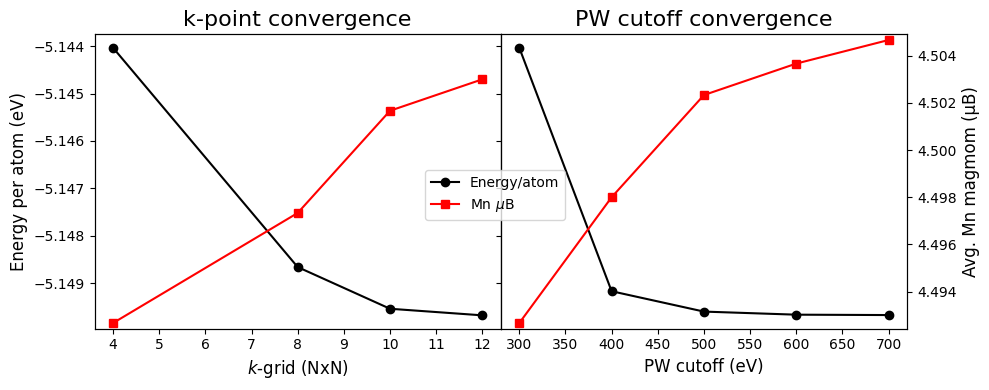

In [78]:
plot_convergence('synthetic.csv', save=True, filename='synthetic.pdf')
